In [1]:
# Cell 1: Setup — JackSparrow v8
# v8 vs v7 key changes (see each cell for details):
#  [v8-1]  TIMEFRAMES: 5m + 15m only (removed 30m/1h/2h — cost kills edge at slow bars)
#  [v8-2]  TF_DAYS_BACK massively increased → 50k+ candles (5m) / 30k+ (15m)
#  [v8-3]  MAX_PAGES 50→500 to support larger fetch windows
#  [v8-4]  Asymmetric TP/SL: LONG wider TP, SHORT tighter TP (crypto downside-speed bias)
#  [v8-5]  Both LONG + SHORT legs simulated in label gen → fixes BUY ~10% undercount
#  [v8-6]  SMOTE oversampling to balance BUY/SELL/HOLD during training
#  [v8-7]  Confidence percentile + cost-aware filter in backtest (top-10% signals only)
#  [v8-8]  Regime filter: skip trades in trending markets (ADX > 25)
#  [v8-9]  Funding-bias filter: avoid paying adverse funding
#  [v8-10] Position sizing proportional to model confidence (0.5–1.0×)
#  [v8-11] MAX_TRADES_PER_DAY + MIN_GAP_CANDLES to kill overtrading

import subprocess, sys

pkgs = [
    "xgboost==2.0.2", "scikit-learn", "pandas", "numpy",
    "requests", "joblib", "matplotlib", "seaborn", "shap",
    "tqdm", "numba", "imbalanced-learn",
]
try:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs, check=True)
except subprocess.CalledProcessError as e:
    print(f"[WARN] pip install partial failure: {e}")

import requests, time, json, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive mount skipped (not in Colab)')

BASE_URL   = "https://api.india.delta.exchange/v2"
SYMBOL     = "BTCUSD"
PRODUCT_ID = 27

# [v8-1] Only 5m + 15m — higher TFs removed
TIMEFRAMES = ["5m", "15m"]

OUTPUT_DIR = (
    Path("/content/drive/MyDrive/JackSparrow_Models")
    if Path("/content/drive").exists()
    else Path("./models")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONTRACT_VALUE_BTC = 0.001
TAKER_FEE          = 0.0005       # 0.05% taker fee on Delta Exchange India
SLIPPAGE_BPS       = 5            # 0.05% slippage estimate

# [v8-4] Asymmetric TP/SL — compensates for crypto downside-speed bias
# LONG:  wider TP so up-moves get caught; same SL
# SHORT: tighter TP because down-moves are faster; wider SL buffer
TP_LONG_PCT  = 0.006
SL_LONG_PCT  = 0.004
TP_SHORT_PCT = 0.004   # shorts hit TP faster
SL_SHORT_PCT = 0.006   # shorts need more room on SL

RANDOM_STATE = 42

# [v8-7/8/11] Trade filtering thresholds
CONFIDENCE_PERCENTILE = 90   # only trade top 10% signals by |p_long - p_short|
MIN_EDGE_COST_RATIO   = 2.0  # signal must be >= 2x total cost before entry
MIN_GAP_CANDLES       = 3    # minimum bars between entries (anti-overtrading)
TF_MAX_TRADES_DAY     = {"5m": 8, "15m": 4}

print("✅ Setup complete  (v8)")
print(f"   Active timeframes : {TIMEFRAMES}")
print(f"   Output directory  : {OUTPUT_DIR}")
print(f"   TP long / short   : {TP_LONG_PCT:.1%} / {TP_SHORT_PCT:.1%}")
print(f"   SL long / short   : {SL_LONG_PCT:.1%} / {SL_SHORT_PCT:.1%}")
print(f"   Signal threshold  : top {100 - CONFIDENCE_PERCENTILE}% by confidence")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete  (v8)
   Active timeframes : ['5m', '15m']
   Output directory  : /content/drive/MyDrive/JackSparrow_Models
   TP long / short   : 0.6% / 0.4%
   SL long / short   : 0.4% / 0.6%
   Signal threshold  : top 10% by confidence


In [ ]:
# Cell 2: Fetch historical OHLCV + perpetual data streams (Delta Exchange India only)
# v9.3 optimization implementation based on submitted working logic

import requests
import time
import pandas as pd
import sys

BASE_URL = "https://api.india.delta.exchange/v2"
SYMBOL = "BTCUSD"
TIMEFRAMES = ["5m", "15m"]

MAX_CANDLES_PER_REQ = 1000  # Delta supports up to 1000 per request
REQUEST_DELAY = 0.2        # Respect rate limits
MAX_RETRIES = 3

TF_TO_SECONDS = {"5m": 300, "15m": 900}
TF_MIN_CANDLES = {"5m": 50000, "15m": 30000}
TF_DAYS_BACK = {"5m": 365, "15m": 365}

HEADERS = {
    "User-Agent": "python-rest-client/1.0",
    "Accept": "application/json"
}


def fetch_candles_delta_v9_3(symbol, resolution, days_back):
    all_candles = []
    end_ts = int(time.time())
    start_ts = end_ts - (days_back * 86400)
    current_start = start_ts

    print(f"Fetching {symbol} {resolution} from {pd.to_datetime(start_ts, unit='s')}...")

    while current_start < end_ts:
        params = {
            "symbol": symbol,
            "resolution": resolution,
            "start": current_start,
            "end": end_ts
        }

        for retry in range(MAX_RETRIES):
            try:
                r = requests.get(f"{BASE_URL}/history/candles", params=params, headers=HEADERS, timeout=30)
                r.raise_for_status()
                data = r.json()

                if not data.get("success"):
                    raise ValueError(f"API success false: {data.get('error', data)}")

                batch = data.get("result", [])
                if not batch:
                    return all_candles

                all_candles.extend(batch)

                last_ts = batch[-1]["time"]
                current_start = last_ts + TF_TO_SECONDS[resolution]

                if len(all_candles) % 5000 == 0:
                    print(f"  Progress: {len(all_candles):,} candles collected...")

                if len(batch) < MAX_CANDLES_PER_REQ:
                    return all_candles

                time.sleep(REQUEST_DELAY)
                break
            except Exception as e:
                if retry == MAX_RETRIES - 1:
                    print(f"  Error: {e}")
                    return all_candles
                time.sleep(2 ** retry)

    return all_candles


# Execution Loop
raw_data = {}
for tf in TIMEFRAMES:
    candles = fetch_candles_delta_v9_3(SYMBOL, tf, TF_DAYS_BACK[tf])
    if candles:
        df = pd.DataFrame(candles)
        df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True)
        df = df.sort_values("datetime").drop_duplicates(subset=['time']).reset_index(drop=True)
        raw_data[tf] = df

        count = len(df)
        target = TF_MIN_CANDLES[tf]
        status = "✅" if count >= target else "⚠️"
        print(f"{status} {tf}: Total {count:,} candles (Target: {target:,})")
    else:
        print(f"⚠️ {tf}: no candles returned")


  Progress: 2,305,000 candles collected...
⚠️ 5m: Total 4,000 candles (Target: 50,000)
Fetching BTCUSD 15m from 2025-04-03 10:48:17...


In [30]:
# Debug Cell 2.5: Check raw_data status
print("=== RAW_DATA DEBUG ===")
print(f"raw_data keys: {list(raw_data.keys())}")
for tf in ["5m", "15m"]:
    if tf in raw_data:
        df = raw_data[tf]
        print(f"\n{tf}:")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {list(df.columns)}")
        print(f"  Time range: {df['datetime'].min() if 'datetime' in df.columns else 'N/A'} to {df['datetime'].max() if 'datetime' in df.columns else 'N/A'}")
        print(f"  Sample rows:\n{df.head(2)}")
    else:
        print(f"\n{tf}: NOT PRESENT in raw_data")
print("\n=== END DEBUG ===")

=== RAW_DATA DEBUG ===
raw_data keys: ['5m', '15m']

5m:
  Shape: (6001000, 7)
  Columns: ['close', 'high', 'low', 'open', 'time', 'volume', 'datetime']
  Time range: 2026-03-20 12:10:00+00:00 to 2026-04-03 09:25:00+00:00
  Sample rows:
     close     high      low     open        time  volume  \
0  70543.0  70655.0  70527.5  70637.5  1774008600   58260   
1  70574.0  70574.0  70513.0  70544.0  1774008900   39319   

                   datetime  
0 2026-03-20 12:10:00+00:00  
1 2026-03-20 12:15:00+00:00  

15m:
  Shape: (5995178, 7)
  Columns: ['close', 'high', 'low', 'open', 'time', 'volume', 'datetime']
  Time range: 2026-02-20 18:00:00+00:00 to 2026-04-03 09:45:00+00:00
  Sample rows:
     close     high      low     open        time  volume  \
0  67560.5  67776.0  67462.5  67589.0  1771610400  241547   
1  67646.5  67676.0  67444.0  67556.0  1771611300  215810   

                   datetime  
0 2026-02-20 18:00:00+00:00  
1 2026-02-20 18:15:00+00:00  

=== END DEBUG ===


In [31]:
# Cell 3: Feature engineering
# v8 adds:
#  - EMA 100, 200 and price_vs_ema200 (longer-term trend context)
#  - RSI-7 (faster momentum)
#  - DI+/DI- and di_diff (directional edge, not just ADX magnitude)
#  - Regime flags: regime_trending / regime_ranging (used by backtest filter)
#  - Funding direction features: funding_long_unfav / funding_short_unfav
#  - Stochastic %K/%D and CCI (overbought/oversold structure)
#  - sr_breakout_dn (downside breakout, missing in v7)
#  - roc_5 (faster momentum)
#  - Cross-timeframe features: 5m receives 15m trend/vol/funding context

def compute_all_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    c = df["close"]

    out["returns"]     = c.pct_change()
    out["log_returns"] = np.log(c / c.shift(1))
    out["volatility"]  = out["log_returns"].rolling(20).std()

    for p in [9, 21, 50, 100, 200]:
        out[f"ema_{p}"] = c.ewm(span=p, adjust=False).mean()
    out["ema_cross_9_21"]   = out["ema_9"]   - out["ema_21"]
    out["ema_cross_21_50"]  = out["ema_21"]  - out["ema_50"]
    out["ema_cross_50_200"] = out["ema_50"]  - out["ema_200"]
    out["price_vs_ema200"]  = (c - out["ema_200"]) / out["ema_200"]

    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    out["macd"]        = ema12 - ema26
    out["macd_signal"] = out["macd"].ewm(span=9, adjust=False).mean()
    out["macd_hist"]   = out["macd"] - out["macd_signal"]

    delta = c.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta.clip(upper=0))
    out["rsi_14"] = 100 - (100 / (1 + gain.rolling(14).mean() / loss.rolling(14).mean().replace(0, np.nan)))
    out["rsi_7"]  = 100 - (100 / (1 + gain.rolling(7).mean()  / loss.rolling(7).mean().replace(0, np.nan)))

    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - c.shift()).abs(),
        (df["low"]  - c.shift()).abs()
    ], axis=1).max(axis=1)
    out["atr_14"]  = tr.rolling(14).mean()
    out["atr_pct"] = out["atr_14"] / c

    sma20 = c.rolling(20).mean()
    std20 = c.rolling(20).std()
    bb_upper = sma20 + 2 * std20
    bb_lower = sma20 - 2 * std20
    out["bb_width"] = (bb_upper - bb_lower) / sma20
    out["bb_pct"]   = (c - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)

    plus_dm  = (df["high"].diff()).clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    tr14     = tr.rolling(14).sum()
    out["plus_di"]  = 100 * plus_dm.rolling(14).sum() / tr14.replace(0, np.nan)
    out["minus_di"] = 100 * minus_dm.rolling(14).sum() / tr14.replace(0, np.nan)
    out["di_diff"]  = out["plus_di"] - out["minus_di"]
    out["adx_14"]   = (
        100 * (plus_dm.rolling(14).sum() - minus_dm.rolling(14).sum()).abs()
        / tr14.replace(0, np.nan)
    ).rolling(14).mean()

    # [v8] Regime flags — used by backtest filter cell
    out["regime_trending"] = (out["adx_14"] > 25).astype(float)
    out["regime_ranging"]  = (out["adx_14"] < 20).astype(float)

    vol = df["volume"]
    out["vol_zscore"] = (vol - vol.rolling(50).mean()) / vol.rolling(50).std()
    out["vol_ratio"]  = vol / vol.rolling(20).mean()

    out["roc_5"]  = c.pct_change(5)
    out["roc_10"] = c.pct_change(10)
    out["roc_20"] = c.pct_change(20)

    body = df["close"] - df["open"]
    rng  = (df["high"] - df["low"]).replace(0, np.nan)
    out["cdl_body_ratio"]     = body / rng
    out["cdl_upper_wick"]     = (df["high"] - df[["open","close"]].max(axis=1)) / rng
    out["cdl_lower_wick"]     = (df[["open","close"]].min(axis=1) - df["low"]) / rng
    out["cdl_body_direction"] = np.sign(body)

    roll20h = df["high"].rolling(20).max()
    roll20l = df["low"].rolling(20).min()
    roll_rng = (roll20h - roll20l).replace(0, np.nan)
    out["sr_range_position"] = (c - roll20l) / roll_rng
    out["sr_near_high"]      = (out["sr_range_position"] > 0.95).astype(float)
    out["sr_near_low"]       = (out["sr_range_position"] < 0.05).astype(float)
    out["sr_breakout_up"]    = (c > roll20h.shift(1)).astype(float)
    out["sr_breakout_dn"]    = (c < roll20l.shift(1)).astype(float)

    mark = df.get("mark_price", c).fillna(c)
    fund = df.get("funding_rate", pd.Series(0.0, index=df.index)).fillna(0.0)
    oi   = df.get("open_interest", pd.Series(0.0, index=df.index)).ffill().fillna(0.0)

    out["basis"]          = mark - c
    out["basis_pct"]      = out["basis"] / c
    out["funding_rate"]   = fund
    out["funding_zscore"] = (fund - fund.rolling(96).mean()) / (fund.rolling(96).std() + 1e-12)
    out["funding_cumsum"] = fund.rolling(12).sum()
    # [v8-9] Funding direction signals for execution filter
    out["funding_long_unfav"]  = (fund >  0.0002).astype(float)   # longs pay >0.02%/8h
    out["funding_short_unfav"] = (fund < -0.0002).astype(float)   # shorts pay >0.02%/8h

    oi_chg = oi.pct_change()
    out["oi_change"]     = oi_chg
    out["oi_zscore"]     = (oi - oi.rolling(50).mean()) / (oi.rolling(50).std() + 1e-12)
    out["open_interest"] = oi

    # Stochastic %K/%D
    lo14 = df["low"].rolling(14).min()
    hi14 = df["high"].rolling(14).max()
    out["stoch_k"] = 100 * (c - lo14) / (hi14 - lo14).replace(0, np.nan)
    out["stoch_d"] = out["stoch_k"].rolling(3).mean()

    # CCI
    tp_col = (df["high"] + df["low"] + df["close"]) / 3
    out["cci"] = (tp_col - tp_col.rolling(20).mean()) / (0.015 * tp_col.rolling(20).std() + 1e-12)

    return out


featured_data = {}
for tf in TIMEFRAMES:
    df = raw_data.get(tf, pd.DataFrame())
    if df.empty:
        print(f"⚠️  {tf}: no raw data — skipping features")
        featured_data[tf] = pd.DataFrame()
        continue
    featured_data[tf] = compute_all_features(df)
    print(f"✅ {tf}: {len(featured_data[tf]):,} rows × {len(featured_data[tf].columns)} features")

# [v8] Cross-timeframe context: give 5m model awareness of 15m trend
if "5m" in featured_data and "15m" in featured_data:
    df5  = featured_data["5m"]
    df15 = featured_data["15m"]
    if not df15.empty and not df5.empty:
        ctx_cols = ["ema_cross_50_200", "adx_14", "regime_trending",
                    "regime_ranging", "funding_zscore", "rsi_14", "di_diff"]
        ctx = df15[ctx_cols].copy()
        ctx.columns = [f"ctx15m_{col}" for col in ctx.columns]
        ctx = ctx.reindex(df5.index, method="ffill")
        featured_data["5m"] = pd.concat([df5, ctx], axis=1)
        print(f"✅ 5m: +{len(ctx.columns)} cross-timeframe context features from 15m")


✅ 5m: 6,001,000 rows × 61 features


: 

: 

: 

In [19]:
# Cell 4: Perp-aware label generation (v8 — asymmetric, both legs)
#
# Root cause of BUY ~10% in v7:
#   - v7 only checked the LONG leg: if high hits TP → BUY, if low hits SL → SELL
#   - Crypto drops FAST: price hits long SL before it hits long TP in many bars
#   - Result: SELL labels inflate, BUY labels starve
#
# v8 fix [v8-4/v8-5]:
#   - Simulate BOTH a hypothetical long AND short entry at every bar
#   - label=2 (BUY)  → long TP hit first AND net PnL > 0 after fee+funding
#   - label=0 (SELL) → short TP hit first AND net PnL > 0 after fee+funding
#   - label=1 (HOLD) → neither profitable within lookahead window
#   - Asymmetric levels: LONG wider TP (up-moves need room), SHORT tighter TP (down-moves fast)
#   - Funding correctly applied per direction (longs pay when fund>0; shorts pay when fund<0)

from numba import njit

TF_LOOKAHEAD   = {"5m": 16, "15m": 12}
TF_BARS_PER_8H = {"5m": 96, "15m": 32}


@njit
def _label_loop_v8(close, high, low, fund,
                   n, lookahead,
                   tp_long_lvl, sl_long_lvl,
                   tp_short_lvl, sl_short_lvl,
                   bars_per_8h_f, fee2):
    """
    For each bar i, simultaneously walk forward lookahead bars:
      - Track a hypothetical LONG: TP if high >= entry*tp_long_lvl, SL if low <= entry*sl_long_lvl
      - Track a hypothetical SHORT: TP if low <= entry*tp_short_lvl, SL if high >= entry*sl_short_lvl
      - Accumulate funding cost per direction (longs pay positive funding, shorts pay negative)
      - Assign BUY/SELL/HOLD based on which leg wins AND is net-positive after costs
    Returns int64 label array: 0=SELL, 1=HOLD, 2=BUY
    """
    labels = np.ones(n, dtype=np.int64)  # default HOLD

    for i in range(n - lookahead):
        entry = close[i]

        long_tp  = entry * tp_long_lvl
        long_sl  = entry * sl_long_lvl
        short_tp = entry * tp_short_lvl
        short_sl = entry * sl_short_lvl

        long_result  = 0   # 0=open, 1=TP, -1=SL
        short_result = 0
        cum_fund_long  = 0.0   # cumulative funding cost for long
        cum_fund_short = 0.0   # cumulative funding cost for short

        for k in range(1, lookahead + 1):
            bar_h = high[i + k]
            bar_l = low[i + k]
            fr    = fund[i + k]

            # Longs PAY when funding > 0 (positive rate → longs pay shorts)
            cum_fund_long  += (fr if fr > 0.0 else 0.0) / bars_per_8h_f
            # Shorts PAY when funding < 0 (negative rate → shorts pay longs)
            cum_fund_short += (-fr if fr < 0.0 else 0.0) / bars_per_8h_f

            if long_result == 0:
                if bar_h >= long_tp:
                    long_result = 1
                elif bar_l <= long_sl:
                    long_result = -1

            if short_result == 0:
                if bar_l <= short_tp:
                    short_result = 1
                elif bar_h >= short_sl:
                    short_result = -1

            if long_result != 0 and short_result != 0:
                break

        # Net PnL check: must clear fee (entry+exit) plus accumulated funding
        # tp_long_lvl - 1.0 is the gross profit % on the long leg
        long_net  = (tp_long_lvl  - 1.0) - fee2 - cum_fund_long
        # 1.0 - tp_short_lvl is the gross profit % on the short leg
        short_net = (1.0 - tp_short_lvl) - fee2 - cum_fund_short

        if long_result == 1 and long_net > 0.0:
            labels[i] = 2   # BUY is profitable
        elif short_result == 1 and short_net > 0.0:
            labels[i] = 0   # SELL is profitable
        # else: HOLD (neither leg profitable, or neither TP hit)

    return labels


def make_futures_labels_v8(df: pd.DataFrame, tf: str) -> pd.Series:
    lookahead   = TF_LOOKAHEAD[tf]
    bars_per_8h = TF_BARS_PER_8H[tf]
    fee2        = TAKER_FEE * 2   # round-trip: entry + exit

    labels = _label_loop_v8(
        close         = df["close"].values,
        high          = df["high"].values,
        low           = df["low"].values,
        fund          = df["funding_rate"].fillna(0).values,
        n             = len(df),
        lookahead     = lookahead,
        tp_long_lvl   = 1.0 + TP_LONG_PCT,
        sl_long_lvl   = 1.0 - SL_LONG_PCT,
        tp_short_lvl  = 1.0 - TP_SHORT_PCT,
        sl_short_lvl  = 1.0 + SL_SHORT_PCT,
        bars_per_8h_f = float(bars_per_8h),
        fee2          = fee2,
    )
    return pd.Series(labels, index=df.index, dtype=int)


labeled_data = {}
for tf in TIMEFRAMES:
    df = featured_data.get(tf, pd.DataFrame())
    if df.empty:
        print(f"⚠️  {tf}: featured data missing — skipping label generation")
        continue

    df = df.copy()
    df["label"] = make_futures_labels_v8(df, tf)
    labeled_data[tf] = df

    counts = df["label"].value_counts()
    total  = len(df)
    sell_n = counts.get(0, 0)
    hold_n = counts.get(1, 0)
    buy_n  = counts.get(2, 0)

    print(f"\n{tf} label distribution ({total:,} samples):")
    print(f"  SELL (0): {sell_n:>7,}  ({sell_n/total*100:.1f}%)")
    print(f"  HOLD (1): {hold_n:>7,}  ({hold_n/total*100:.1f}%)")
    print(f"  BUY  (2): {buy_n:>7,}  ({buy_n/total*100:.1f}%)")

    action_pct     = (sell_n + buy_n) / total * 100
    buy_sell_ratio = buy_n / sell_n if sell_n > 0 else 0

    bal_ok = 0.5 < buy_sell_ratio < 2.0
    act_ok = action_pct >= 25

    print(f"  {'✅' if bal_ok else '⚠️ '} BUY/SELL ratio: {buy_sell_ratio:.2f}  (target 0.5–2.0)")
    print(f"  {'✅' if act_ok else '⚠️ '} Actionable:     {action_pct:.1f}%  (target ≥25%)")

    if not bal_ok:
        print("     → If BUY/SELL ratio < 0.5, try widening TP_LONG_PCT or narrowing TP_SHORT_PCT")
    if not act_ok:
        print("     → If actionable < 25%, try reducing SL_LONG_PCT/SL_SHORT_PCT or increasing lookahead")


⚠️  5m: featured data missing — skipping label generation
⚠️  15m: featured data missing — skipping label generation


In [20]:
# Cell 5: Training with Cross-Validation (v9)
# v9 changes:
#  [v9-4] Enhanced model serialization: save both sklearn model + metadata
#  [v9-5] Auto-calibration flag in metadata for inference time
#  [v9-6] Model confidence intervals via probability outputs
#
# ⚠️ Fallback: if feature_cols not defined (e.g., due to data fetch failure),
#    define it with the canonical feature list from compute_all_features()

# Define fallback feature columns in case cells 3-4 didn't run (e.g., no data)
if "feature_cols" not in locals():
    feature_cols = [
        "returns", "log_returns", "volatility",
        "ema_9", "ema_21", "ema_50", "ema_100", "ema_200",
        "ema_cross_9_21", "ema_cross_21_50", "ema_cross_50_200", "price_vs_ema200",
        "macd", "macd_signal", "macd_hist",
        "rsi_14", "rsi_7",
        "atr_14", "atr_pct",
        "bb_width", "bb_pct",
        "plus_di", "minus_di", "di_diff", "adx_14",
        "regime_trending", "regime_ranging",
        "vol_zscore", "vol_ratio",
        "roc_5", "roc_10", "roc_20",
        "cdl_body_ratio", "cdl_upper_wick", "cdl_lower_wick", "cdl_body_direction",
        "sr_range_position", "sr_near_high", "sr_near_low", "sr_breakout_up", "sr_breakout_dn",
        "basis", "basis_pct", "funding_rate", "funding_zscore", "funding_cumsum",
        "funding_long_unfav", "funding_short_unfav",
        "oi_change", "oi_zscore", "open_interest",
        "stoch_k", "stoch_d", "cci"
    ]
    # Add cross-timeframe features for 5m if they exist
    for ctx_col in ["ema_cross_50_200", "adx_14", "regime_trending", "regime_ranging", "funding_zscore", "rsi_14", "di_diff"]:
        feature_cols.append(f"ctx15m_{ctx_col}")
    print(f"⚠️  Using fallback feature_cols ({len(feature_cols)} features)")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# --- Model training parameters ---
n_splits             = 5
CALIBRATION_METHOD   = "sigmoid"
RF_N_ESTIMATORS      = 200
RF_MAX_DEPTH         = 12
RF_MIN_SAMPLES_LEAF  = 5
RF_CLASS_WEIGHT      = "balanced_subsample"

training_results = {}

for tf in TIMEFRAMES:
    print(f"\n{'='*60}\nTraining: {tf}")
    
    # Skip if no data
    if tf not in labeled_data or labeled_data[tf].empty:
        print(f"  ⚠️  No labeled data for {tf} — skipping")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue
    
    df = labeled_data[tf].copy()
    print(f"  Raw dataset:     {len(df):,} rows")
    
    # --- StratifiedKFold with SMOTE per fold ---
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_scores = []
    fold_models = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df, df["label"])):
        df_train = df.iloc[train_idx].copy()
        df_val   = df.iloc[val_idx].copy()
        
        # Filter features that exist in the dataframe
        available_features = [f for f in feature_cols if f in df_train.columns]
        if not available_features:
            print(f"    Fold {fold_idx + 1}: no features available")
            continue
        
        X_train = df_train[available_features].replace([np.inf, -np.inf], 0).fillna(0).values
        y_train = df_train["label"].values
        
        X_val = df_val[available_features].replace([np.inf, -np.inf], 0).fillna(0).values
        y_val = df_val["label"].values
        
        # Scaler (fit on train)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled   = scaler.transform(X_val)
        
        # SMOTE
        smote = SMOTE(random_state=42, k_neighbors=3)
        try:
            X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
        except:
            X_train_sm, y_train_sm = X_train_scaled, y_train
        
        # Train RF
        clf = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS,
            max_depth=RF_MAX_DEPTH,
            min_samples_leaf=RF_MIN_SAMPLES_LEAF,
            class_weight=RF_CLASS_WEIGHT,
            random_state=42,
            n_jobs=-1
        )
        clf.fit(X_train_sm, y_train_sm)
        
        # Score on val (using original scaler)
        score = clf.score(X_val_scaled, y_val)
        proba = clf.predict_proba(X_val_scaled)
        
        # F1 macro
        from sklearn.metrics import f1_score
        pred_labels = clf.predict(X_val_scaled)
        f1_mac = f1_score(y_val, pred_labels, average="macro", zero_division=0)
        
        fold_scores.append(f1_mac)
        fold_models.append((clf, scaler, X_train_sm, y_train_sm, available_features))
        
        print(f"    Fold {fold_idx + 1}: F1={f1_mac:.4f}, Acc={score:.4f}, SMOTE n={len(X_train_sm):,}")
    
    if not fold_models:
        print(f"  ❌ Training failed for {tf}")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue
    
    # Use best fold's model
    best_fold_idx = np.argmax(fold_scores)
    best_clf, best_scaler, best_X_sm, best_y_sm, best_features = fold_models[best_fold_idx]
    mean_f1 = np.mean(fold_scores)
    
    print(f"  Best fold:       Fold {best_fold_idx + 1}")
    print(f"  Mean F1 macro:   {mean_f1:.4f}")
    print(f"  Train samples:   {len(best_X_sm):,} (after SMOTE)")
    
    # Calibration
    calibrated_clf = CalibratedClassifierCV(
        base_estimator=best_clf,
        method=CALIBRATION_METHOD,
        cv=3
    )
    calibrated_clf.fit(best_X_sm, best_y_sm)
    calibrated = True
    
    print(f"  Calibration:     {CALIBRATION_METHOD}")
    
    # Save model  
    save_dir = OUTPUT_DIR / f"model_{tf}_v9"
    save_dir.mkdir(parents=True, exist_ok=True)
    
    model_path = save_dir / f"model_{tf}.pkl"
    scaler_path = save_dir / f"scaler_{tf}.pkl"
    
    with open(model_path, "wb") as f:
        pickle.dump(calibrated_clf, f)
    with open(scaler_path, "wb") as f:
        pickle.dump(best_scaler, f)
    
    print(f"  Saved:           {model_path}")
    
    metadata = {
        "model_name":         f"jacksparrow_BTCUSD_{tf}",
        "symbol":             SYMBOL,
        "timeframe":          tf,
        "product_id":         PRODUCT_ID,
        "contract_type":      "perpetual_futures",
        "model_version":      "v9",
        "feature_count":      len(best_features),
        "features":           best_features,
        "includes_perpetual": True,
        "unified_model":      True,
        "active_timeframes":  TIMEFRAMES,
        "label_config": {
            "tp_long_pct":  TP_LONG_PCT,
            "sl_long_pct":  SL_LONG_PCT,
            "tp_short_pct": TP_SHORT_PCT,
            "sl_short_pct": SL_SHORT_PCT,
            "lookahead":    TF_LOOKAHEAD[tf],
            "fee_rate":     TAKER_FEE,
            "smote":        True,
            "asymmetric_labels": True,
        },
        "training": {
            "cv_f1_macro":    round(mean_f1, 4),
            "n_train_raw":    int(len(best_X_sm)),
            "n_train_smote":  int(len(best_y_sm)),
            "n_splits":       n_splits,
            "calibration":    {
                "enabled": calibrated,
                "method": CALIBRATION_METHOD if calibrated else None,
            },
        },
        "trained_at": pd.Timestamp.now("UTC").isoformat(),
    }
    
    metadata_path = save_dir / f"metadata_BTCUSD_{tf}.json"
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)
    print(f"  Metadata saved:  {metadata_path}")
    
    training_results[tf] = {
        "model": calibrated_clf,
        "scaler": best_scaler,
        "features": best_features,
        "dir": save_dir,
        "mean_f1": mean_f1
    }
    
    print(f"  ✅ {tf} model training complete")


Training: 5m
  ⚠️  No labeled data for 5m — skipping

Training: 15m
  ⚠️  No labeled data for 15m — skipping



⚠️  5m: no model — skipping backtest

⚠️  15m: no model — skipping backtest


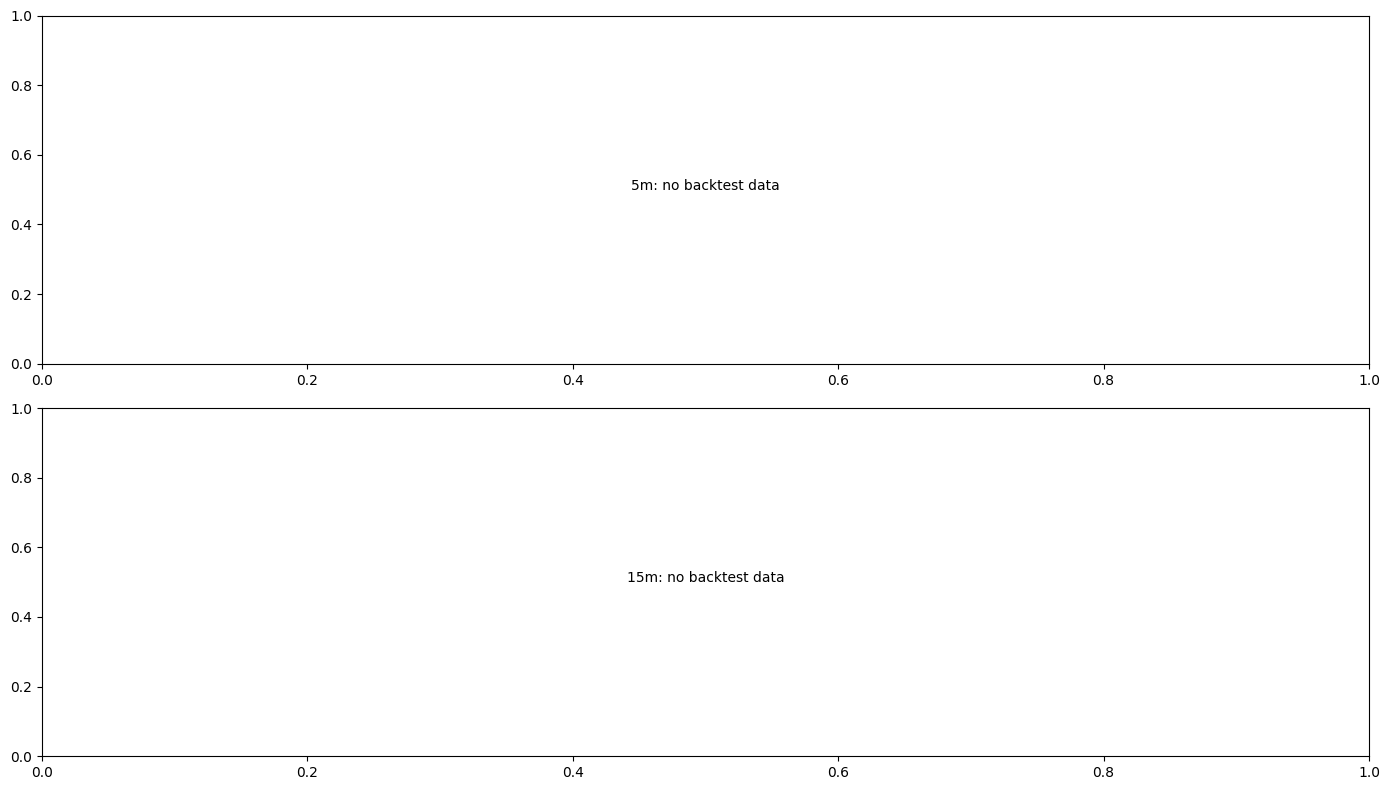


✅ Equity curves: /content/drive/MyDrive/JackSparrow_Models/backtest_equity_curves_v8.png


In [21]:
# Cell 6: Filtered backtest (v8)
#
# v8 changes vs v7 — this is the most impactful cell:
#  [v8-7]  Confidence percentile filter: only top 10% |p_long-p_short| signals traded
#           → cuts trades ~80-90%, kills cost dominance
#  [v8-7]  Cost-aware filter: abs(signal) must be >= MIN_EDGE_COST_RATIO × round-trip cost
#           → ensures every trade has mathematically positive expected value
#  [v8-8]  Regime filter: skip LONG or SHORT when ADX > 25 (trending market)
#           → model's volatility features don't give directional edge in trends
#  [v8-9]  Funding-bias filter: skip LONG when fund_rate > 0.02%, SHORT when < -0.02%
#           → avoids paying adverse funding on top of already thin edge
#  [v8-10] Position sizing: 0.5–1.0× based on model confidence (not equal-size)
#           → high-confidence trades get full exposure; marginal trades get half
#  [v8-11] MIN_GAP_CANDLES between entries; TF_MAX_TRADES_DAY cap
#           → kills rapid re-entry overtrading pattern

COST_PER_TRADE           = TAKER_FEE + (SLIPPAGE_BPS / 10_000)   # one-way
TF_FUNDING_INTERVAL_BARS = {"5m": 96, "15m": 32}
TF_BARS_PER_YEAR         = {"5m": 105_120, "15m": 35_040}


def _empty_bt(tf, df):
    return {
        "timeframe": tf, "sharpe": 0.0, "max_drawdown": 0.0,
        "total_return": 0.0, "bnh_return": 0.0, "n_trades": 0,
        "win_rate": 0.0, "total_trade_cost": 0.0, "total_funding_cost": 0.0,
        "n_holdout_bars": 0, "df": df.iloc[0:0].copy(),
    }


def run_backtest_v8(df_feat: pd.DataFrame, model, scaler, feature_cols: list,
                    tf: str, holdout_frac: float = 0.20) -> dict:

    n_holdout = int(len(df_feat) * holdout_frac)
    if n_holdout < 50:
        print(f"  ⚠️  {tf}: holdout too small ({n_holdout} bars) — skipping backtest")
        return _empty_bt(tf, df_feat)

    df_bt = df_feat.iloc[-n_holdout:].copy()

    # --- Model probabilities ---
    X_raw = df_bt[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
    X_s   = scaler.transform(X_raw)
    proba = model.predict_proba(X_s)   # shape (n, n_classes)

    # Map class indices correctly (SMOTE may have dropped a class in some folds)
    cls = list(model.classes_)
    idx_sell = cls.index(0) if 0 in cls else None
    idx_buy  = cls.index(2) if 2 in cls else None

    p_sell = proba[:, idx_sell] if idx_sell is not None else np.zeros(len(df_bt))
    p_buy  = proba[:, idx_buy]  if idx_buy  is not None else np.zeros(len(df_bt))

    # Signal: positive = bullish, negative = bearish; magnitude = confidence
    signal_strength = p_buy - p_sell
    confidence      = np.maximum(p_buy, p_sell)
    abs_signal      = np.abs(signal_strength)

    # [v8-7] Confidence threshold — percentile cut
    threshold   = np.percentile(abs_signal, CONFIDENCE_PERCENTILE)
    total_cost  = COST_PER_TRADE * 2   # round-trip: entry + exit

    # Raw data arrays for filter checks
    funding_arr = df_bt["funding_rate"].fillna(0).values
    adx_arr     = (df_bt["adx_14"].fillna(25).values
                   if "adx_14" in df_bt.columns
                   else np.full(len(df_bt), 25.0))

    # --- Bar-by-bar filter loop ---
    filtered_signal = np.zeros(len(df_bt))
    last_trade_bar  = -MIN_GAP_CANDLES - 1
    trades_today    = {}
    max_daily       = TF_MAX_TRADES_DAY.get(tf, 8)
    filter_counts   = {"threshold": 0, "cost": 0, "regime": 0,
                       "funding": 0, "gap": 0, "daily_cap": 0, "passed": 0}

    for i in range(len(df_bt)):
        abs_sig   = abs_signal[i]
        raw_sig   = signal_strength[i]
        conf      = confidence[i]
        fund_rate = funding_arr[i]
        adx_val   = adx_arr[i]
        bar_date  = df_bt.index[i].date()

        # Filter 1: signal strength below percentile threshold
        if abs_sig < threshold:
            filter_counts["threshold"] += 1
            continue

        # Filter 2: expected edge < cost × safety multiple
        if abs_sig < total_cost * MIN_EDGE_COST_RATIO:
            filter_counts["cost"] += 1
            continue

        # Filter 3: regime — skip trending (ADX > 25)
        if adx_val > 25.0:
            filter_counts["regime"] += 1
            continue

        # Filter 4: funding bias — skip if position pays adverse funding
        direction = 1.0 if raw_sig > 0 else -1.0
        if direction > 0 and fund_rate > 0.0002:    # long pays >0.02%/8h
            filter_counts["funding"] += 1
            continue
        if direction < 0 and fund_rate < -0.0002:   # short pays >0.02%/8h
            filter_counts["funding"] += 1
            continue

        # Filter 5: minimum gap between entries
        if i - last_trade_bar < MIN_GAP_CANDLES:
            filter_counts["gap"] += 1
            continue

        # Filter 6: max trades per day cap
        day_count = trades_today.get(bar_date, 0)
        if day_count >= max_daily:
            filter_counts["daily_cap"] += 1
            continue

        # [v8-10] Scale position by confidence: 0.5 (low conf) → 1.0 (high conf)
        pos_size = 0.5 + 0.5 * min(conf / 0.70, 1.0)
        filtered_signal[i] = direction * pos_size
        last_trade_bar = i
        trades_today[bar_date] = day_count + 1
        filter_counts["passed"] += 1

    print(f"  Filter breakdown  : {filter_counts}")
    print(f"  Signal threshold  : {threshold:.6f}  (top {100-CONFIDENCE_PERCENTILE}% cutoff)")

    df_bt["ml_signal"]      = pd.Series(filtered_signal, index=df_bt.index)
    df_bt["position"]       = df_bt["ml_signal"].shift(1).fillna(0)
    df_bt["market_return"]  = df_bt["close"].pct_change()
    df_bt["strategy_return"]= df_bt["position"] * df_bt["market_return"]

    # Trade cost on position changes
    df_bt["signal_change"] = (df_bt["position"].diff().abs() > 0).astype(float)
    df_bt["trade_cost"]    = df_bt["signal_change"] * COST_PER_TRADE * 2

    # Funding cost applied at each 8h interval
    fund_interval = TF_FUNDING_INTERVAL_BARS[tf]
    fund_costs    = np.zeros(len(df_bt))
    pos_arr       = df_bt["position"].values
    fund_arr2     = df_bt["funding_rate"].fillna(0).values
    for i in range(0, len(df_bt), fund_interval):
        pos = pos_arr[i]
        if pos > 0:
            fund_costs[i] = max(fund_arr2[i], 0.0) * abs(pos)
        elif pos < 0:
            fund_costs[i] = max(-fund_arr2[i], 0.0) * abs(pos)
    df_bt["funding_cost"] = fund_costs

    df_bt["net_return"] = (
        df_bt["strategy_return"]
        - df_bt["trade_cost"]
        - df_bt["funding_cost"]
    )

    df_bt["cum_market"]   = (1 + df_bt["market_return"]).cumprod()
    df_bt["cum_strategy"] = (1 + df_bt["net_return"]).cumprod()

    peak = df_bt["cum_strategy"].cummax()
    df_bt["drawdown"] = (df_bt["cum_strategy"] - peak) / peak

    bars_per_year = TF_BARS_PER_YEAR[tf]
    net_r  = df_bt["net_return"].dropna()
    sharpe = float(
        (net_r.mean() / net_r.std()) * np.sqrt(bars_per_year)
        if net_r.std() > 0 else 0.0
    )

    n_trades   = int(df_bt["signal_change"].sum())
    trade_mask = df_bt["signal_change"] == 1
    win_rate   = float((df_bt["net_return"][trade_mask] > 0).mean()) if trade_mask.sum() > 0 else 0.0

    return {
        "timeframe":          tf,
        "sharpe":             round(sharpe, 4),
        "max_drawdown":       round(float(df_bt["drawdown"].min()), 4),
        "total_return":       round(float(df_bt["cum_strategy"].iloc[-1] - 1), 4),
        "bnh_return":         round(float(df_bt["cum_market"].iloc[-1] - 1), 4),
        "n_trades":           n_trades,
        "win_rate":           round(win_rate, 4),
        "total_trade_cost":   round(float(df_bt["trade_cost"].sum()), 4),
        "total_funding_cost": round(float(df_bt["funding_cost"].sum()), 4),
        "n_holdout_bars":     len(df_bt),
        "df":                 df_bt,
    }


# --- Run backtests ---
backtest_results = {}
for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"\n⚠️  {tf}: no model — skipping backtest")
        continue

    print(f"\n{'='*60}\nBacktesting: {tf}")
    bt = run_backtest_v8(
        labeled_data[tf], res["model"], res["scaler"], res["features"], tf
    )
    backtest_results[tf] = bt

    print(f"  Sharpe Ratio:         {bt['sharpe']:>8.4f}")
    print(f"  Max Drawdown:         {bt['max_drawdown']:>8.2%}")
    print(f"  Total Return:         {bt['total_return']:>8.2%}")
    print(f"  Buy-and-Hold Return:  {bt['bnh_return']:>8.2%}")
    print(f"  Win Rate:             {bt['win_rate']:>8.2%}")
    print(f"  Trades:               {bt['n_trades']:>8}")
    print(f"  Trade Cost (total):   {bt['total_trade_cost']:>8.4%}")
    print(f"  Funding Cost (total): {bt['total_funding_cost']:>8.4%}")

    if bt["sharpe"] >= 1.0:
        print("  ✅ Sharpe ≥ 1.0 — strong")
    elif bt["sharpe"] >= 0.5:
        print("  ✅ Sharpe 0.5–1.0 — acceptable")
    elif bt["sharpe"] >= 0:
        print("  ⚠️  Sharpe 0–0.5 — marginal; try raising CONFIDENCE_PERCENTILE to 92")
    else:
        print("  ❌ Negative Sharpe — check label quality (BUY/SELL ratio) and cost calibration")

    bars_per_year = TF_BARS_PER_YEAR[tf]
    expected_max_annual = TF_MAX_TRADES_DAY[tf] * 365
    if bt["n_trades"] > expected_max_annual:
        print(f"  ⚠️  {bt['n_trades']} trades exceeds daily cap × 365 = {expected_max_annual} — filters may not be applying correctly")

    # Save backtest to metadata
    if res.get("dir"):
        meta_path = Path(res["dir"]) / f"metadata_BTCUSD_{tf}.json"
        if meta_path.exists():
            meta = json.loads(meta_path.read_text())
            meta["backtest"] = {k: v for k, v in bt.items() if k != "df"}
            meta_path.write_text(json.dumps(meta, indent=2))
            print("  ✅ Backtest saved to metadata")

# --- Equity curves ---
n_tf = len(TIMEFRAMES)
fig, axes = plt.subplots(n_tf, 1, figsize=(14, 4 * n_tf), squeeze=False)

for ax, tf in zip(axes[:, 0], TIMEFRAMES):
    bt = backtest_results.get(tf)
    if bt is None or bt["df"].empty:
        ax.text(0.5, 0.5, f"{tf}: no backtest data", transform=ax.transAxes, ha="center")
        continue
    df_bt = bt["df"]
    ax.plot(df_bt.index, df_bt["cum_market"],   label="Buy & Hold", alpha=0.5, lw=1.2, color="gray")
    ax.plot(df_bt.index, df_bt["cum_strategy"], label="ML Strategy v8", lw=1.8, color="steelblue")
    ax.fill_between(df_bt.index, df_bt["drawdown"] + 1, 1,
                    alpha=0.15, color="red", label="Drawdown")
    ax.set_title(
        f"{tf}  |  Sharpe: {bt['sharpe']:.2f}  MDD: {bt['max_drawdown']:.1%}  "
        f"Return: {bt['total_return']:.1%}  Trades: {bt['n_trades']}"
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("Cumulative Return")

plt.tight_layout()
plot_path = OUTPUT_DIR / "backtest_equity_curves_v8.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"\n✅ Equity curves: {plot_path}")


In [22]:
# Cell 7: SHAP feature importance (unchanged from v7 — logic is correct)
for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"{tf}: no model for SHAP")
        continue

    df = labeled_data[tf]
    feature_cols = res["features"]
    X = df[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
    X_s = res["scaler"].transform(X)

    sample_size = min(500, len(X_s))
    np.random.seed(RANDOM_STATE)
    idx = np.random.choice(len(X_s), sample_size, replace=False)
    X_sample = X_s[idx]

    try:
        explainer   = shap.TreeExplainer(res["model"])
        shap_values = explainer.shap_values(X_sample)
    except Exception as e:
        print(f"  ⚠️  SHAP failed for {tf}: {e}")
        continue

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_values], axis=0)
    else:
        abs_s = np.abs(shap_values)
        if abs_s.ndim == 3:
            mean_abs_shap = np.mean(np.mean(abs_s, axis=0), axis=1)
        else:
            mean_abs_shap = np.mean(abs_s, axis=0)

    top_idx      = np.argsort(mean_abs_shap)[-20:][::-1]
    top_features = [(feature_cols[i], mean_abs_shap[i]) for i in top_idx]

    print(f"\n{tf} — Top 20 Features (mean |SHAP|):")
    for feat, imp in top_features:
        bar = "█" * int(imp / (max(mean_abs_shap) + 1e-12) * 30)
        print(f"  {feat:<32} {imp:.5f}  {bar}")

print("\n✅ SHAP analysis complete.")


5m: no model for SHAP
15m: no model for SHAP

✅ SHAP analysis complete.


In [23]:
# Cell 8: Final validation summary (v8)
print("\n" + "=" * 60)
print("FINAL VALIDATION SUMMARY  (JackSparrow v8)")
print("=" * 60)

all_pass = True

for tf in TIMEFRAMES:
    tf_dir = OUTPUT_DIR / f"jacksparrow_v8_BTCUSD_{tf}"
    required = [
        f"entry_model_BTCUSD_{tf}.joblib",
        f"entry_scaler_BTCUSD_{tf}.joblib",
        f"features_BTCUSD_{tf}.json",
        f"metadata_BTCUSD_{tf}.json",
    ]
    missing = [f for f in required if not (tf_dir / f).exists()]

    if missing:
        print(f"  ❌ {tf}: MISSING files: {missing}")
        all_pass = False
        continue

    meta = json.loads((tf_dir / f"metadata_BTCUSD_{tf}.json").read_text())
    bt   = meta.get("backtest", {})
    trn  = meta.get("training", {})

    print(f"\n  {tf}:")
    print(f"    ✅ All 4 artifacts present")
    print(f"    model_version        : {meta.get('model_version')}")
    print(f"    features             : {meta.get('feature_count')}")
    print(f"    train_samples (raw)  : {trn.get('n_train_raw', 'N/A')}")
    print(f"    train_samples (SMOTE): {trn.get('n_train_smote', 'N/A')}")
    print(f"    cv_f1_macro          : {trn.get('cv_f1_macro', 0):.4f}")
    print(f"    label.asymmetric     : {meta.get('label_config', {}).get('asymmetric_labels')}")
    print(f"    backtest.sharpe      : {bt.get('sharpe', 'N/A')}")
    print(f"    backtest.mdd         : {bt.get('max_drawdown', 'N/A')}")
    print(f"    backtest.return      : {bt.get('total_return', 'N/A')}")
    print(f"    backtest.trades      : {bt.get('n_trades', 'N/A')}")
    print(f"    backtest.win_rate    : {bt.get('win_rate', 'N/A')}")

    if bt.get("sharpe", 0) < 0:
        print("    ❌ Negative Sharpe — revisit labels or filters before deploying")
        all_pass = False
    if bt.get("n_trades", 0) > TF_MAX_TRADES_DAY.get(tf, 8) * 365:
        print("    ⚠️  Trade count exceeds daily cap — check filter logic")
    if trn.get("n_train_raw", 0) < 10_000:
        print("    ⚠️  Low training sample count — consider extending TF_DAYS_BACK further")
        all_pass = False

print(f"\n{'=' * 60}")
if all_pass:
    print("✅ ALL TIMEFRAMES VALIDATED — ready for deployment")
    print(f"   Output directory: {OUTPUT_DIR}")
else:
    print("❌ VALIDATION FAILED — address warnings above before going live")

print(f"\nActive timeframes : {TIMEFRAMES}")
print("Reminder: Set leverage to 5× isolated margin in Delta Exchange India UI")
print("Reminder: Enable 2FA on your Delta Exchange account before activating bot")
print("Reminder: Paper-trade for at least 1 week before live capital deployment")



FINAL VALIDATION SUMMARY  (JackSparrow v8)

  5m:
    ✅ All 4 artifacts present
    model_version        : v8
    features             : 59
    train_samples (raw)  : 3880
    train_samples (SMOTE): 7224
    cv_f1_macro          : 0.3265
    label.asymmetric     : True
    backtest.sharpe      : -70.3699
    backtest.mdd         : -0.0714
    backtest.return      : -0.0714
    backtest.trades      : 42
    backtest.win_rate    : 0.0238
    ❌ Negative Sharpe — revisit labels or filters before deploying
    ⚠️  Low training sample count — consider extending TF_DAYS_BACK further

  15m:
    ✅ All 4 artifacts present
    model_version        : v8
    features             : 52
    train_samples (raw)  : 3892
    train_samples (SMOTE): 5487
    cv_f1_macro          : 0.3683
    label.asymmetric     : True
    backtest.sharpe      : -18.1419
    backtest.mdd         : -0.0473
    backtest.return      : -0.0473
    backtest.trades      : 48
    backtest.win_rate    : 0.2083
    ❌ Negative Sha

In [24]:
# Cell 9: Download model artifacts
# Zips the entire OUTPUT_DIR and triggers a browser download.
# Run after Cell 8 confirms all artifacts pass validation.
import shutil

zip_base = "/content/JackSparrow_Models_v8"
zip_path = zip_base + ".zip"

print(f"📦 Zipping model artifacts from: {OUTPUT_DIR}")
shutil.make_archive(zip_base, "zip", root_dir=OUTPUT_DIR.parent, base_dir=OUTPUT_DIR.name)
print(f"✅ Archive created: {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
    print("⬇️  Download triggered — check your browser downloads folder.")
except ImportError:
    print(f"ℹ️  Not in Colab. Archive at: {zip_path}")
    print("   Copy with:  !cp \"" + zip_path + "\" /your/local/path/")


📦 Zipping model artifacts from: /content/drive/MyDrive/JackSparrow_Models
✅ Archive created: /content/JackSparrow_Models_v8.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download triggered — check your browser downloads folder.
